In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sec_nlp.data_handling.sampling import sample


In [2]:
data_path = Path.cwd().parent / 'data' / 'clean'
target_path = Path.cwd().parent / 'data' / 'samples' / 'cleaning_notebook_sample.parquet'
sample_path = sample(src=data_path, out=target_path, seed=87)
sample_df = pd.read_parquet(sample_path)


Sampling from 25 file(s). Reservoir size: 10,000 rows


  0%|          | 0/25 [00:00<?, ?file/s]

Total number of rows: 211,307 rows
Sample size: 10,000 rows
Output: /home/james/code/personal_projects/sec_filings/data/samples/cleaning_notebook_sample.parquet  (816.2 MB)


In [3]:
sample_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   filename    10000 non-null  object
 1   cik         10000 non-null  int64 
 2   year        10000 non-null  int64 
 3   section_1   8812 non-null   object
 4   section_1A  5070 non-null   object
 5   section_1B  796 non-null    object
 6   section_2   8763 non-null   object
 7   section_3   8591 non-null   object
 8   section_4   4534 non-null   object
 9   section_5   9383 non-null   object
 10  section_6   7611 non-null   object
 11  section_7   8972 non-null   object
 12  section_7A  6836 non-null   object
 13  section_8   8917 non-null   object
 14  section_9   2656 non-null   object
 15  section_9A  6084 non-null   object
 16  section_9B  1423 non-null   object
 17  section_10  8512 non-null   object
 18  section_11  8171 non-null   object
 19  section_12  8558 non-null   object
 20  section

In [4]:
sample_df[sample_df['format'].isna()]


,filename,cik,year,section_1,section_1A,section_1B,section_2,section_3,section_4,section_5,...,section_9,section_9A,section_9B,section_10,section_11,section_12,section_13,section_14,section_15,format


In [5]:
section_cols = [c for c in sample_df.columns if c.startswith('section_')]

# Filings where every section is null — likely a full parse failure
all_null_mask = sample_df[section_cols].isna().all(axis=1)
print(f"Fully-null filings: {all_null_mask.sum()}")
sample_df[all_null_mask][['filename', 'cik', 'year', 'format']].head(10)


Fully-null filings: 65


,filename,cik,year,format
123,1219370_2003.txt,1219370,2003,txt
321,1346065_2005.txt,1346065,2005,txt
452,1050524_1997.txt,1050524,1997,txt
604,1025365_1998.txt,1025365,1998,txt
874,793628_1999.txt,793628,1999,txt
969,830750_1997.txt,830750,1997,txt
1086,798941_2009.htm,798941,2009,htm
1099,9749_2001.txt,9749,2001,txt
1339,1112682_2008.htm,1112682,2008,htm
1750,906598_1996.txt,906598,1996,txt


In [6]:
import re

HTML_ENTITY = re.compile(r'&[a-zA-Z]{2,6};|&#\d+;')
REPEATED_HEADER = re.compile(r'^\s*item\s+\d+[a-z]?[\.\s]', re.IGNORECASE)
EXCESSIVE_NEWLINES = re.compile(r'\n{4,}')

def _flag_issues(text):
    if not isinstance(text, str):
        return pd.Series({'html_entities': False, 'repeated_header': False, 'excessive_newlines': False})
    return pd.Series({
        'html_entities': bool(HTML_ENTITY.search(text)),
        'repeated_header': bool(REPEATED_HEADER.match(text)),
        'excessive_newlines': bool(EXCESSIVE_NEWLINES.search(text)),
    })

# Check section_1 as a representative sample
issues = sample_df['section_1'].apply(_flag_issues)
print("In section_1 (non-null only):")
print(issues[sample_df['section_1'].notna()].mean().mul(100).round(1).to_string(), "%")


In section_1 (non-null only):
html_entities         0.0
repeated_header       0.1
excessive_newlines    0.0 %


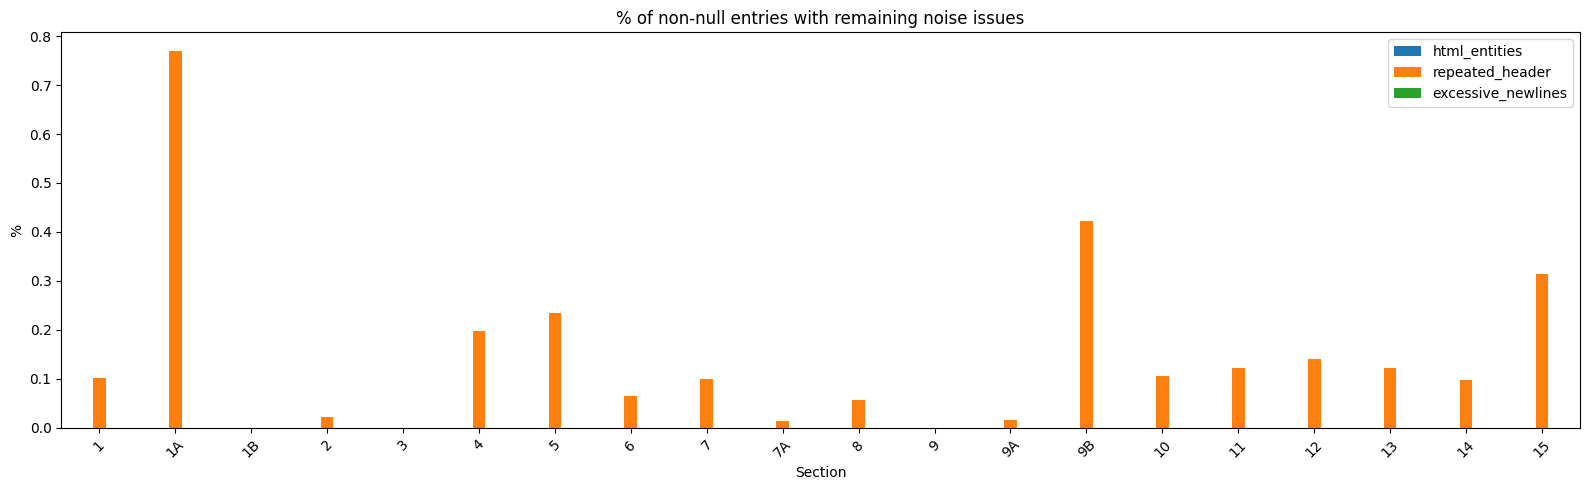

In [7]:
# Spread the issue check across all sections
issue_rates = {}
for col in section_cols:
    non_null = sample_df[col].dropna()
    if len(non_null) == 0:
        continue
    flags = non_null.apply(_flag_issues)
    issue_rates[col.replace('section_', '')] = flags.mean().mul(100)

issue_df = pd.DataFrame(issue_rates).T

fig, ax = plt.subplots(figsize=(16, 5))
issue_df.plot.bar(ax=ax)
ax.set_title('% of non-null entries with remaining noise issues')
ax.set_ylabel('%')
ax.set_xlabel('Section')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [8]:
# Spot-check: one example of each issue type from section_1
for issue in ['html_entities', 'repeated_header', 'excessive_newlines']:
    mask = issues[issue] & sample_df['section_1'].notna()
    if not mask.any():
        print(f"No {issue} found in section_1\n")
        continue
    example = sample_df.loc[mask.idxmax(), 'section_1']
    print(f"=== {issue} ===")
    print(example[:5_000])
    print()
    

No html_entities found in section_1

=== repeated_header ===
Item 2. Description of Property.
Item 3. Legal Proceedings.
Item 4. Removed and Reserved.
PART II
Item 5. Market for Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities.
Item 6. Selected Financial Data.
Item 7. Management’s Discussion and Analysis of Financial Condition and Plan of Operation.
Item 7A. Quantitative and Qualitative Disclosure About Market Risk.
Item 8. Financial Statements and Supplementary Data.
Item 9. Changes In and Disagreements with Accountants on Accounting and Financial Disclosure.
Item 9A. Controls and Procedures.
Item 9B. Other Information
PART III
Item 10. Directors, Executive Officers and Corporate Governance
Item 11. Executive Compensation
Item 12. Security Ownership of Certain Beneficial Owners and Management and Related Stockholder Matters.
Item 13. Certain Relationships and Related Transactions and Director Independence.
Item 14. Principal Accounting Fees and Serv

In [9]:
# Spot-check: one example of each issue type from section_7
for issue in ['html_entities', 'repeated_header', 'excessive_newlines']:
    mask = issues[issue] & sample_df['section_7'].notna()
    if not mask.any():
        print(f"No {issue} found in section_7\n")
        continue
    example = sample_df.loc[mask.idxmax(), 'section_7']
    print(f"=== {issue} ===")
    print(example[:5_000])
    print()
    

No html_entities found in section_7

=== repeated_header ===
When used in this Form 10-K and in our future filings with the Securities and Exchange Commission, the words or phrases will likely result, management expects, or we expect, will continue, is anticipated, estimated or similar expressions are intended to identify forward-looking statements within the meaning of the Private Securities Litigation Reform Act of 1995. Readers are cautioned not to place undue reliance on any such forward-looking statements, each of which speak only as of the date made. These statements are subject to risks and uncertainties, some of which are described below. Actual results may differ materially from historical earnings and those presently anticipated or projected. We have no obligation to publicly release the result of any revisions that may be made to any forward-looking statements to reflect anticipated events or circumstances occurring after the date of such statements.
Plan of Operation
We hav

## Section length distributions

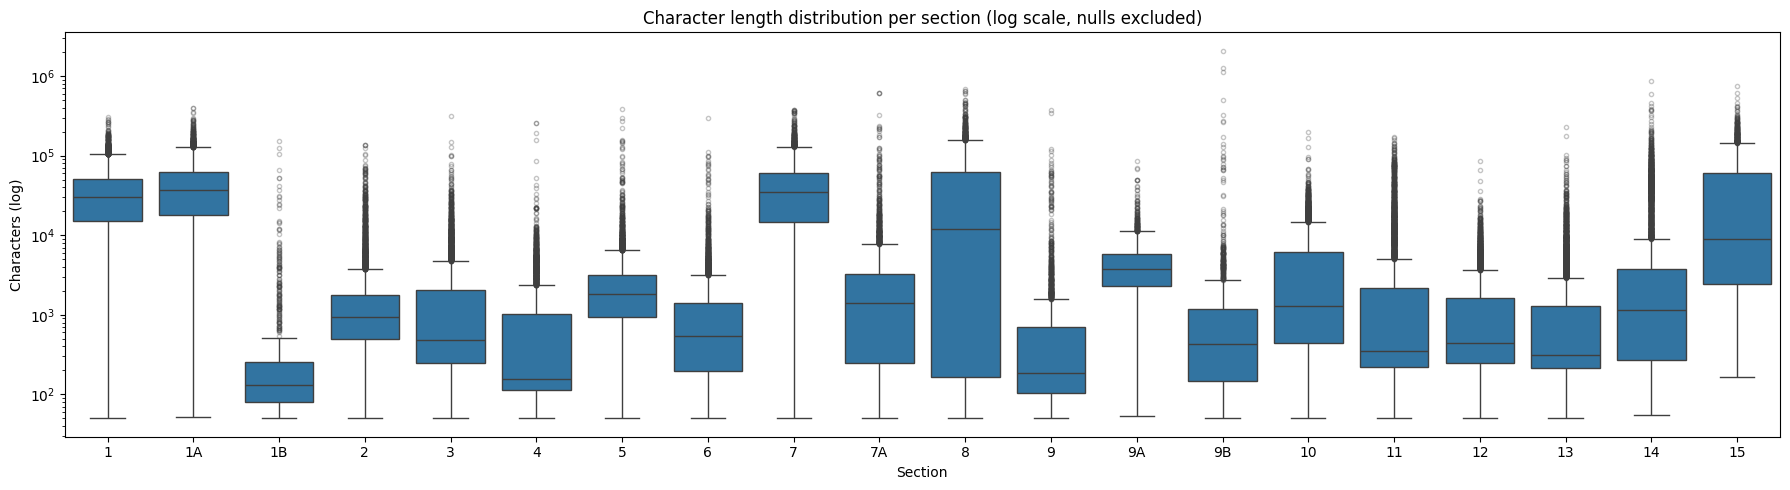

          count     mean      std    min      25%      50%      75%       95%        max
section                                                                                 
1        8812.0  37725.0  31742.0   50.0  15146.0  30016.0  50638.0  100347.0   303251.0
10       8512.0   4477.0   7427.0   50.0    440.0   1292.0   6189.0   18201.0   198709.0
11       8171.0   4234.0  12185.0   50.0    221.0    350.0   2148.0   21066.0   171897.0
12       8558.0   1452.0   2666.0   50.0    248.0    438.0   1624.0    5914.0    84982.0
13       8227.0   1901.0   5832.0   50.0    215.0    314.0   1300.0    8595.0   228676.0
14       9142.0   8930.0  25969.0   55.0    269.0   1144.0   3766.0   51593.0   870988.0
15       7004.0  36016.0  51711.0  165.0   2422.0   9026.0  59654.0  134280.0   757620.0
1A       5070.0  45919.0  41405.0   52.0  18095.0  36501.0  61728.0  128717.0   395472.0
1B        796.0   1619.0   9182.0   50.0     80.0    130.0    252.0    4745.0   152289.0
2        8763.0   218

In [10]:
lengths = (
    sample_df[section_cols]
    .apply(lambda s: s.str.len())
    .stack()
    .reset_index(level=1)
    .rename(columns={'level_1': 'section', 0: 'length'})
)
lengths['section'] = lengths['section'].str.replace('section_', '', regex=False)

fig, ax = plt.subplots(figsize=(18, 5))
order = [c.replace('section_', '') for c in section_cols]
sns.boxplot(data=lengths, x='section', y='length', order=order, ax=ax, flierprops=dict(marker='.', alpha=0.3))
ax.set_yscale('log')
ax.set_title('Character length distribution per section (log scale, nulls excluded)')
ax.set_xlabel('Section')
ax.set_ylabel('Characters (log)')
plt.tight_layout()
plt.show()

print(lengths.groupby('section')['length'].describe(percentiles=[.25, .5, .75, .95]).round(0).to_string())

## Null rate by year
Older filings (pre-2000, txt format) tend to have lower parse coverage. Useful to know before modelling.

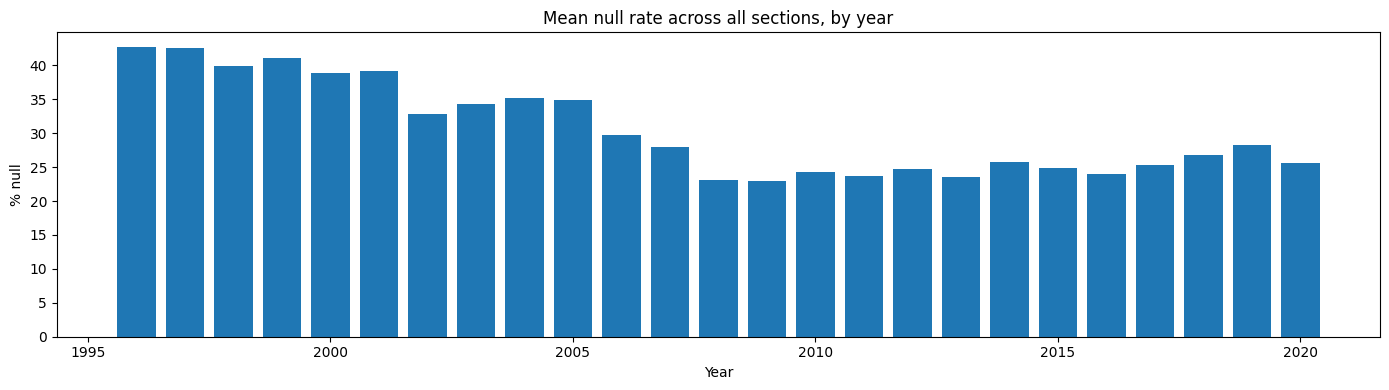

Mean null rate by format:
format
htm     25.0
html    42.0
txt     42.4


In [11]:
null_by_year = (
    sample_df.groupby('year')[section_cols]
    .apply(lambda g: g.isna().mean())
    .mean(axis=1)
    .rename('null_rate')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(null_by_year['year'], null_by_year['null_rate'] * 100)
ax.set_title('Mean null rate across all sections, by year')
ax.set_xlabel('Year')
ax.set_ylabel('% null')
plt.tight_layout()
plt.show()

# Also break down by format
null_by_format = (
    sample_df.groupby('format')[section_cols]
    .apply(lambda g: g.isna().mean().mean())
    .rename('null_rate')
)
print("Mean null rate by format:")
print((null_by_format * 100).round(1).to_string())

## "Incorporated by reference" cross-references
Many short sections are just pointers (e.g. "See Item 7A"). These pass the stub threshold but are content-free for NLP.

In [12]:
IBR_RE = re.compile(r'incorporat\w+\s+herein\s+by\s+reference|incorporated\s+by\s+reference', re.IGNORECASE)

ibr_rates = {}
for col in section_cols:
    non_null = sample_df[col].dropna()
    if len(non_null) == 0:
        continue
    ibr_rates[col.replace('section_', '')] = non_null.str.contains(IBR_RE).mean() * 100

ibr_series = pd.Series(ibr_rates, name='% containing IBR phrase')
print("Sections with 'incorporated by reference' language:")
print(ibr_series.sort_values(ascending=False).round(1).to_string())

# Spot-check: sections that are *only* a cross-reference (short + IBR phrase)
ibr_only_mask = (
    sample_df['section_7A'].notna()
    & sample_df['section_7A'].str.contains(IBR_RE, na=False)
    & (sample_df['section_7A'].str.len() < 500)
)
print(f"\nsection_7A short IBR-only entries: {ibr_only_mask.sum()}")
if ibr_only_mask.any():
    print(sample_df.loc[ibr_only_mask, 'section_7A'].iloc[0])

Sections with 'incorporated by reference' language:
15    66.4
11    57.8
14    57.6
10    56.8
13    55.6
12    54.3
9B    25.1
1     18.3
5     17.4
8     13.4
7     12.2
9     11.2
6      8.4
7A     7.8
1A     7.5
9A     6.5
3      4.8
2      2.6
4      1.8
1B     1.6

section_7A short IBR-only entries: 432
The information in “Management’s Discussion and Analysis of Financial Condition and Results of Operations-Risk Management” in Item 7 of this report is incorporated herein by reference.
ITEM 8.


## Windows-1252 encoding artifacts
Older txt filings decoded as UTF-8 can contain bytes in the 0x80–0x9F range (smart quotes, em-dashes etc.) that are unmapped in Unicode. The new pipeline translates these, but this cell checks the sample for any remaining control characters or suspicious bytes.

In [13]:
CONTROL_CHARS_RE = re.compile(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f-\x9f]')
SMART_QUOTE_RE = re.compile(r'[\x91-\x94\x96\x97]')  # Win-1252 quotes/dashes as raw bytes

artifact_rates = {}
for col in section_cols:
    non_null = sample_df[col].dropna()
    if len(non_null) == 0:
        continue
    artifact_rates[col.replace('section_', '')] = {
        'control_chars_%': non_null.str.contains(CONTROL_CHARS_RE).mean() * 100,
        'win1252_quotes_%': non_null.str.contains(SMART_QUOTE_RE).mean() * 100,
    }

artifact_df = pd.DataFrame(artifact_rates).T
print("Encoding artifact rates per section:")
print(artifact_df.round(2).to_string())

# Find an example if any exist
for col in section_cols:
    mask = sample_df[col].str.contains(CONTROL_CHARS_RE, na=False)
    if mask.any():
        print(f"\nExample from {col}:")
        ex = sample_df.loc[mask.idxmax(), col]
        print(repr(ex[:300]))
        break
else:
    print("\nNo control-character artifacts found in this sample.")

Encoding artifact rates per section:
    control_chars_%  win1252_quotes_%
1              0.00               0.0
1A             0.02               0.0
1B             0.00               0.0
2              0.00               0.0
3              0.00               0.0
4              0.00               0.0
5              0.00               0.0
6              0.00               0.0
7              0.00               0.0
7A             0.01               0.0
8              0.00               0.0
9              0.00               0.0
9A             0.00               0.0
9B             0.00               0.0
10             0.01               0.0
11             0.01               0.0
12             0.01               0.0
13             0.01               0.0
14             0.02               0.0
15             0.00               0.0

Example from section_1A:
'The Company faces many risks. The risks described below may not be the only risks the Company faces. Additional risks not yet known or cur